<a href="https://colab.research.google.com/github/rmilde/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Assignment%203/Econ_5200_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

## Phase 1

In [52]:
# simulation data
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [53]:
num_resamples = 10000

medians = []

for _ in range(num_resamples):
  sample = np.random.choice(driver_tips, size = 250, replace = True)
  medians.append(np.median(sample))

np.percentile(medians, [2.5, 97.5])

array([0.26530184, 1.36356392])

In [54]:
np.median(driver_tips)

np.float64(0.7553316913699188)

The confidence interval is not symmetric around the the true driver_tips median, whcih is 0.755. This is because we created this data set to be skewed, as tip data often is. It has many observations around 0 and a few large outliers. The uppderbound, as in 1.366 is further away from 0.755, than the lowerbound, 0.264, is.

## Phase 2

The Problem: The engineering division claims their newly deployed "Batch Routing" algorithm significantly decreases delivery times. An A/B test was conducted on 1,000 deliveries (500 Control, 500 Treatment). However, while the treatment generally performs well, it contains extreme upper-bound outliers caused by software crash loops, entirely invalidating the homoscedasticity assumption of a standard T-test.

Task: Generate the synthetic A/B test data. Use a Normal distribution for Control (mean=35m, sd=5m) and a heavily skewed Log-Normal distribution for Treatment (mean=3.4, sigma=0.4). Calculate the observed simple difference in means (Control - Treatment).

In [55]:
# Generate the synthetic A/B test data
control = np.random.normal(35, 5, 500)
treatment = np.random.lognormal(3.4,  0.4, 500)

observed_difference = np.mean(control) - np.mean(treatment)

print(observed_difference)

2.114716590374762


Task: Construct a manual Permutation Test. Concatenate all 1,000 deliveries into a singular array. In a continuous loop of 5,000 iterations, utilize np.random.permutation to shuffle the array, split it arbitrarily into two pseudo-groups of 500, and calculate the simulated difference in means. Finally, calculate the exact empirical P-value: what exact proportion of the 5,000 random permutations yielded differences equal to or more extreme than your observed empirical difference?

In [56]:
# manual Permutation Test

all = np.concatenate([control, treatment])

differences = []

for _ in range(5000):
  shuffled = np.random.permutation(all)

  group_a = shuffled[:500]
  group_b = shuffled[500:]

  difference = np.mean(group_a) - np.mean(group_b)

  differences.append(difference)

count = 0

for diff in differences:
  if diff >= observed_difference:
    count +=1

p_val = count / 5000
print(p_val)


0.0014


## Phase 3

The Problem: The marketing team asserts that users who subscribe to the "SwiftPass" premium loyalty program spend 300% more per month. Based on this, they are requesting to double the acquisition marketing budget. As a trained economist, you instantly recognize severe Selection Bias . High-volume "power users" naturally self-select into the program to save on cumulative delivery fees.

Task: Download the provided swiftcart_loyalty.csv dataset (containing pre-treatment order volume, account age, historical support tickets, and post-treatment spending). Calculate the Naive Simple Difference in Means (SDO) for post-treatment spending explicitly comparing Subscribers (D=1) and Non-Subscribers (D=0).

In [57]:
df = pd.read_csv('swiftcart_loyalty.csv')
df.head()

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227


In [58]:
df_subscriber = df[df['subscriber'] == 1]
df_non_subscriber = df[df['subscriber'] == 0]

sdo = np.mean(df_subscriber['post_spend']) - np.mean(df_non_subscriber['post_spend'])
print(sdo)

17.57066938452379


In [59]:
# Part 1

from sklearn.linear_model import LogisticRegression

x = df[['account_age', 'support_tickets']]
y = df['subscriber']

# fit propensity model
logit = LogisticRegression(solver='liblinear')
logit.fit(x, y)


# generate scores
df['pscore'] = logit.predict_proba(x)[:, 1]

# view the first few propensity scores
df[['subscriber', 'pscore']].head()


,subscriber,pscore
0,1,0.459095
1,1,0.565557
2,1,0.565557
3,1,0.532275
4,1,0.444822


In [60]:
# Part 2
from sklearn.neighbors import NearestNeighbors

df_subscriber = df[df['subscriber'] == 1]
df_non_subscriber = df[df['subscriber'] == 0]

nbrs = NearestNeighbors(n_neighbors=1).fit(df_non_subscriber[['pscore']])
distances, indices = nbrs.kneighbors(df_subscriber[['pscore']])
matched_non_subscriber = df_non_subscriber.iloc[indices.flatten()]

matched_df = pd.concat([df_subscriber, matched_non_subscriber])

print(f"Origional subscriber size: {len(df_subscriber)}")
print(f"Matched non-subscriber size: {len(matched_non_subscriber)}")

Origional subscriber size: 4200
Matched non-subscriber size: 4200


In [61]:
# Part 3

from scipy import stats

# isolate matched outcomes
matched_subscriber = matched_df[matched_df['subscriber'] == 1]['post_spend']
matched_non_subscriber = matched_df[matched_df['subscriber']==0]['post_spend']

# estimate the average treatment effect using the matched data
att = matched_subscriber.mean() - matched_non_subscriber.mean()

print(att)
print(sdo)

18.838665365910337
17.57066938452379


The ATT score of 18.83 means that aftermatching subscribers to similiar non-subscribers we estimat that they spend $18.83 more than their counterpart. This is actually a bigger number than the SDO score of 17.57, showing subrcibers spend that much more than non-subscribers.

## Phase 4

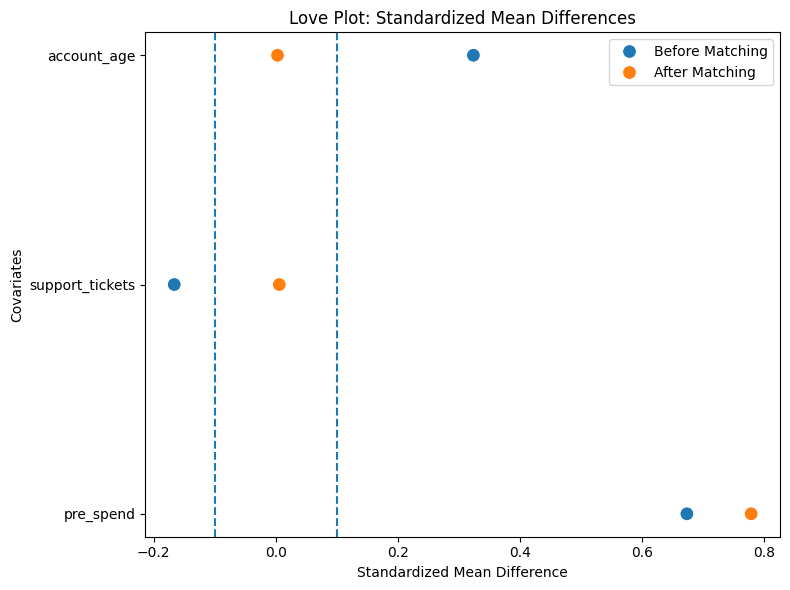

In [62]:
# -----------------------------
# 1. Define covariates used in matching
# -----------------------------
covariates = ['account_age', 'support_tickets', 'pre_spend']

# -----------------------------
# 2. Function to compute SMD
# -----------------------------
def standardized_mean_difference(df, treatment_col, covariate):

    treated = df[df[treatment_col] == 1][covariate]
    control = df[df[treatment_col] == 0][covariate]

    mean_diff = treated.mean() - control.mean()

    pooled_sd = np.sqrt(
        (treated.var() + control.var()) / 2
    )

    return mean_diff / pooled_sd


# -----------------------------
# 3. Compute SMDs Before Matching
# -----------------------------
smd_before = []
for var in covariates:
    smd = standardized_mean_difference(df, 'subscriber', var)
    smd_before.append(smd)

# -----------------------------
# 4. Compute SMDs After Matching
# -----------------------------
smd_after = []
for var in covariates:
    smd = standardized_mean_difference(matched_df, 'subscriber', var)
    smd_after.append(smd)

# -----------------------------
# 5. Create plotting dataframe
# -----------------------------
plot_df = pd.DataFrame({
    'Covariate': covariates * 2,
    'SMD': smd_before + smd_after,
    'Sample': ['Before Matching'] * len(covariates) +
              ['After Matching'] * len(covariates)
})

# -----------------------------
# 6. Plot Love Plot
# -----------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='SMD',
    y='Covariate',
    hue='Sample',
    s=100
)

# Add balance threshold lines
plt.axvline(x=0.1, linestyle='--')
plt.axvline(x=-0.1, linestyle='--')

plt.title('Love Plot: Standardized Mean Differences')
plt.xlabel('Standardized Mean Difference')
plt.ylabel('Covariates')
plt.legend()
plt.tight_layout()
plt.show()